### Task 1:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

insurance_df = pd.read_csv('insurance.csv')

- Largest range of values: Charges, 12k~ - 63k~
- age and bmi are similar in scale
- Because charges will be treated as heavily distant from the smaller scaled features

In [2]:
insurance_df.head()
print(insurance_df.shape)
insurance_df.describe()


(1338, 7)


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### Task 2:

- The scatter plot clustering looks arbitrary, like it's just split into thirds.

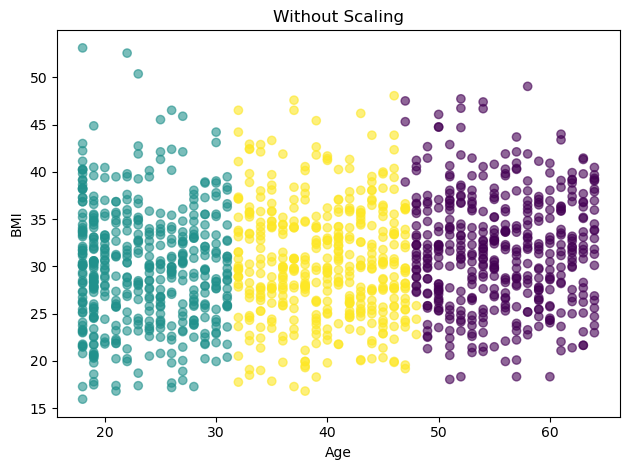

In [3]:
X = insurance_df[['age', 'bmi']]
unscaled_km = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = unscaled_km.fit_predict(X)
insurance_df['unscaled_cluster'] = labels


plt.scatter(insurance_df['age'], insurance_df['bmi'], alpha=0.6, c=insurance_df['unscaled_cluster'], cmap='viridis')
plt.title('Without Scaling')
plt.xlabel('Age')
plt.ylabel('BMI')

plt.tight_layout()
plt.show()

### Task 3

- Our bands became vertical, and you see an interesting transition as older individuals receive higher charges.
- Scaling is important for K-Means as it measures distance, without it, there would be no reliable way for the model to measure how far one data point is from another.

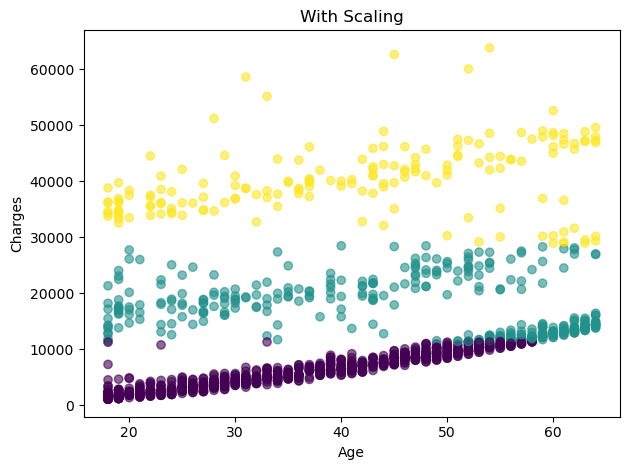

In [4]:
scaler = StandardScaler()
X = insurance_df[['age', 'bmi', 'charges']]
X_scaled = scaler.fit_transform(X)
scaled_km = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = scaled_km.fit_predict(X)
insurance_df['scaled_cluster'] = labels

plt.scatter(insurance_df['age'], insurance_df['charges'], alpha=0.6, c=insurance_df['scaled_cluster'], cmap='viridis')
plt.title('With Scaling')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.tight_layout()
plt.show()

### Task 4 & 5:

- The elbow appears between 3 and 4, this reflects a point in which there is a high enough quantity of clusters, that data points begin to cluster closer to their centroids.
- The highest silhouette score comes from k3, however, it is very close to k4, which offers a significant inertia reduction.
- Silhouette scores reflects how far points are from their nearest neighboring cluster. A higher score reflecting a greater distinction.

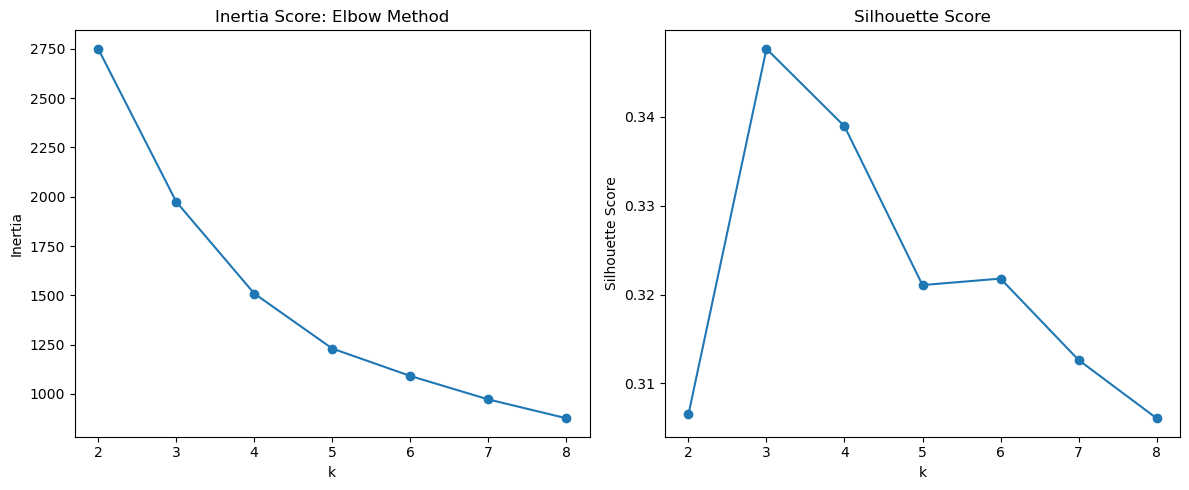

In [5]:
inertias = []
silhouette_scores = []
k_values = range(2, 9)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)  # it and return labels
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# Plot both side by side.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(list(k_values), inertias, marker='o')
axes[0].set_title('Inertia Score: Elbow Method')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(k_values))

axes[1].plot(list(k_values), silhouette_scores, marker='o')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(k_values))

plt.tight_layout()
plt.show()

### Task 6:

- Cluster 0 has older customers, with low BMI and moderate charges.
- Cluster 1 has middle aged customers, with high BMIs and lower charges.
- Cluster 2 has middle aged customers, with high BMIs and significant charges.
- Cluster 3 has young customers, with low BMIS and the lowest charges.

- These groups do make intuitive sense, we're not entirely sure what an insurance company may do with that information, perhaps adjust policy pricing?

In [14]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = km.fit_predict(X_scaled)
insurance_df['final_cluster'] = labels
age_mean = insurance_df.groupby('final_cluster')['age'].mean()
print(f'Age Mean: {age_mean}')
bmi_mean = insurance_df.groupby('final_cluster')['bmi'].mean()
print(f'BMI Mean: {bmi_mean}')
charges_mean = insurance_df.groupby('final_cluster')['charges'].mean()
print(f'Charges Mean: {charges_mean}')

Age Mean: final_cluster
0    51.521851
1    43.969388
2    39.951220
3    26.350305
Name: age, dtype: float64
BMI Mean: final_cluster
0    27.234666
1    37.653673
2    35.371098
3    27.621792
Name: bmi, dtype: float64
Charges Mean: final_cluster
0    14099.147282
1     8801.959335
2    40380.541894
3     6234.362083
Name: charges, dtype: float64


### Task 7:

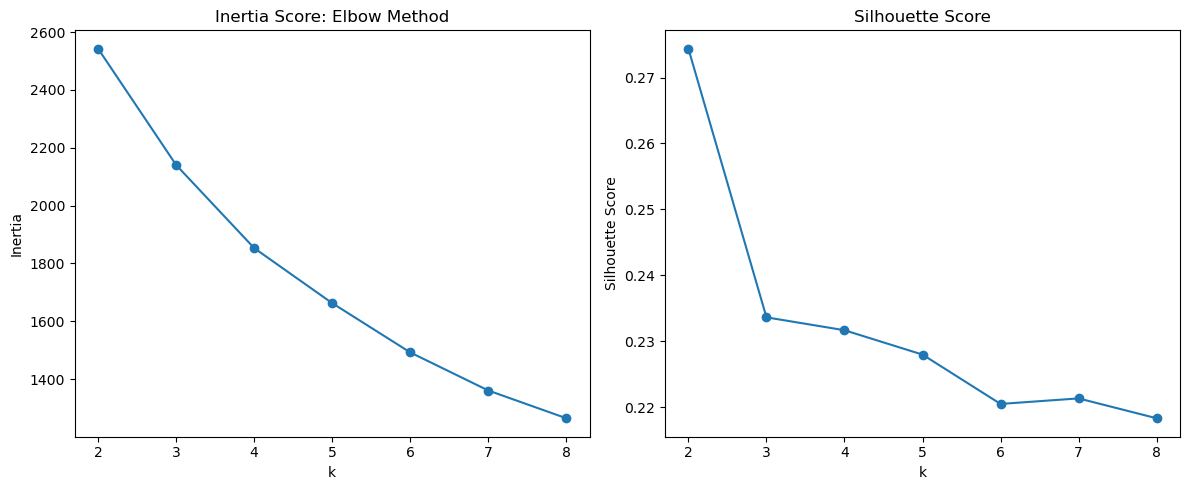

In [18]:
bike_df = pd.read_csv('bike_sharing.csv')
bike_X = bike_df[['temp', 'hum', 'windspeed', 'casual', 'registered']]
bike_X_scaled = scaler.fit_transform(bike_X)

bike_inertias = []
bike_silhouette_scores = []
bike_k_values = range(2, 9)

for k in bike_k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(bike_X_scaled)  # it and return labels
    bike_inertias.append(km.inertia_)
    bike_silhouette_scores.append(silhouette_score(bike_X_scaled, labels))

# Plot both side by side.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(list(bike_k_values), bike_inertias, marker='o')
axes[0].set_title('Inertia Score: Elbow Method')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(bike_k_values))

axes[1].plot(list(bike_k_values), bike_silhouette_scores, marker='o')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(bike_k_values))

plt.tight_layout()
plt.show()

- 0: Average temp and humidity, low winds, and high numbers of riders looks to classify a classification of nice day.
- 1: Cold and windy, low casual participation but relatively stable registered participation.
- 3: Humid and cold, low casual participation but relatively stable registered participation.

In [32]:
bike_km = KMeans(n_clusters=4, random_state=42, n_init=10)
bike_labels = bike_km.fit_predict(bike_X_scaled)
bike_df['cluster'] = bike_labels

temp_mean = bike_df.groupby('cluster')['temp'].mean()
hum_mean = bike_df.groupby('cluster')['hum'].mean()
wind_mean = bike_df.groupby('cluster')['windspeed'].mean()
casual_mean = bike_df.groupby('cluster')['casual'].mean()
registered_mean = bike_df.groupby('cluster')['registered'].mean()

means_df = pd.concat([temp_mean, hum_mean, wind_mean, casual_mean, registered_mean], axis=1)
means_df.head()





,temp,hum,windspeed,casual,registered
cluster,,,,,
0,0.622804,0.633248,0.171371,2145.405405,3826.900901
1,0.312626,0.498343,0.243157,429.584211,2798.157895
2,0.643137,0.620004,0.168495,899.452756,4991.795276
3,0.399086,0.775761,0.177419,407.926136,2547.215909


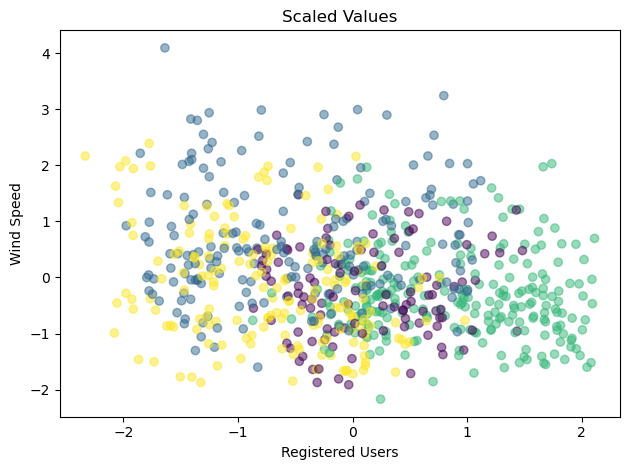

In [38]:
bike_registered_scaled = scaler.fit_transform(bike_df[['registered']])
bike_windspeed_scaled = scaler.fit_transform(bike_df[['windspeed']])
plt.scatter(bike_registered_scaled, bike_windspeed_scaled, alpha=0.5, c=bike_df['cluster'], cmap='viridis')
plt.title('Scaled Values')
plt.xlabel('Registered Users')
plt.ylabel('Wind Speed')
plt.tight_layout()
plt.show()

### Task 8:

- With our parameters, we believe that K-Means is more interpretable. With further tweaking, DBSCAN may surpass it, but the groups are clearer in K-Means. Albeit, the outliers are more obvious with DBSCAN.

Clusters found: 2
Noise points:   51


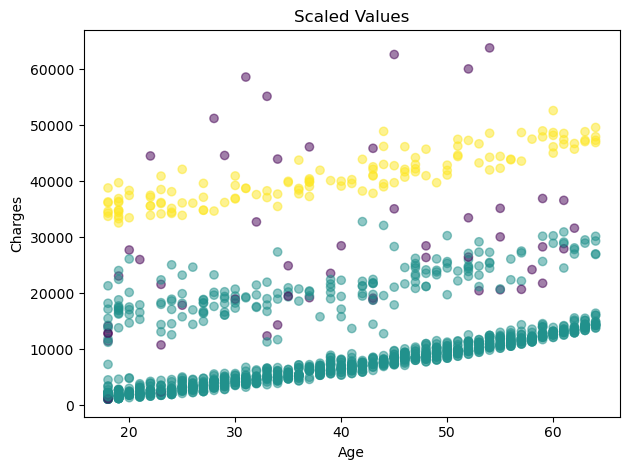

In [58]:
from sklearn.cluster import DBSCAN
db = DBSCAN(eps=.5, min_samples=5)
insurance_df['db_cluster'] = db.fit_predict(X_scaled)
n_clusters = len(set(insurance_df['db_cluster'])) - 1
n_noise = (insurance_df['db_cluster'] == -1).sum()
print(f"Clusters found: {n_clusters}")
print(f"Noise points:   {n_noise}")

plt.scatter(insurance_df[['age']], insurance_df[['charges']], alpha=0.5, c=insurance_df['db_cluster'], cmap='viridis')
plt.title('Scaled Values')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.tight_layout()
plt.show()

### Task 9: